In [123]:

# --- Standard library ---
import random                                    # Python's built-in RNG (seed, uniform, gauss)
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import tensorflow as tf

tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism() 

# --- Third-party libraries: numerical + plotting ---
import numpy as np                               # numerical computing (arrays, arange, hstack, etc.)
import matplotlib.pyplot as plt                  # plotting and visualization (figure, subplot, ax.plot, etc.)

# --- Deep learning framework ---
import tensorflow as tf                          # core TensorFlow library
import tensorflow.keras as keras                 # high-level neural network API

# --- Computer vision library ---
import cv2 as cv                               # OpenCV computer vision library

In [124]:
def relu(x):
    return np.max([0.0,x])

In [125]:
def linear(x):
    return x

In [126]:
def conv(pic, conv_matrix, af=linear, bias=None):
    size_x_conv = conv_matrix.shape[0]
    size_y_conv = conv_matrix.shape[1]

    num_filters = conv_matrix.shape[2]
    
    len_x = pic.shape[0]-size_x_conv+1
    len_y = pic.shape[1]-size_y_conv+1

    num_lines = int(np.ceil(num_filters/10))

    fig = plt.figure(figsize=(20,num_lines*1.5))

    if bias is None:
        bias = np.zeros(num_filters)
    
    nplt = 1
    for f in range(num_filters):
        pic_conv = np.zeros((len_x,len_y))

        for i in range(len_x):
            for j in range(len_y):
                pic_conv[i,j] = af((pic[i:i+size_x_conv,j:j+size_y_conv]*conv_matrix[:,:,f]).sum()+bias[f])
            
        ax = fig.add_subplot(num_lines,10,nplt)
        ax.axis('off')
        ax.set_title(str(f))

        plt.imshow(pic_conv)
        nplt += 1
    return

In [127]:
def plot_samples(xdata, ydata, amount=40):
    for number in range(10):
        indeces = np.random.choice(np.where(ydata == number)[0],size=amount,replace=False)
        fig = plt.figure(figsize=(20,6))
        fig.suptitle("examples for number "+str(number)+":")
        nplt = 1
        for index in indeces:
            ax = fig.add_subplot(4,10,nplt)
            ax.axis('off')
            plt.imshow(xdata[index])
            nplt += 1
    

In [128]:
def rotate_image(image, rotation_angle=0, scale=1):
    height, width = image.shape
    M = cv.getRotationMatrix2D(((width - 1) / 2.0, (height - 1) / 2.0),
                               rotation_angle, scale)
    image_rotated = cv.warpAffine(np.squeeze(image), M, (width, height))

    return image_rotated

# Data Preparation 
## MNIST dataset

In [129]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


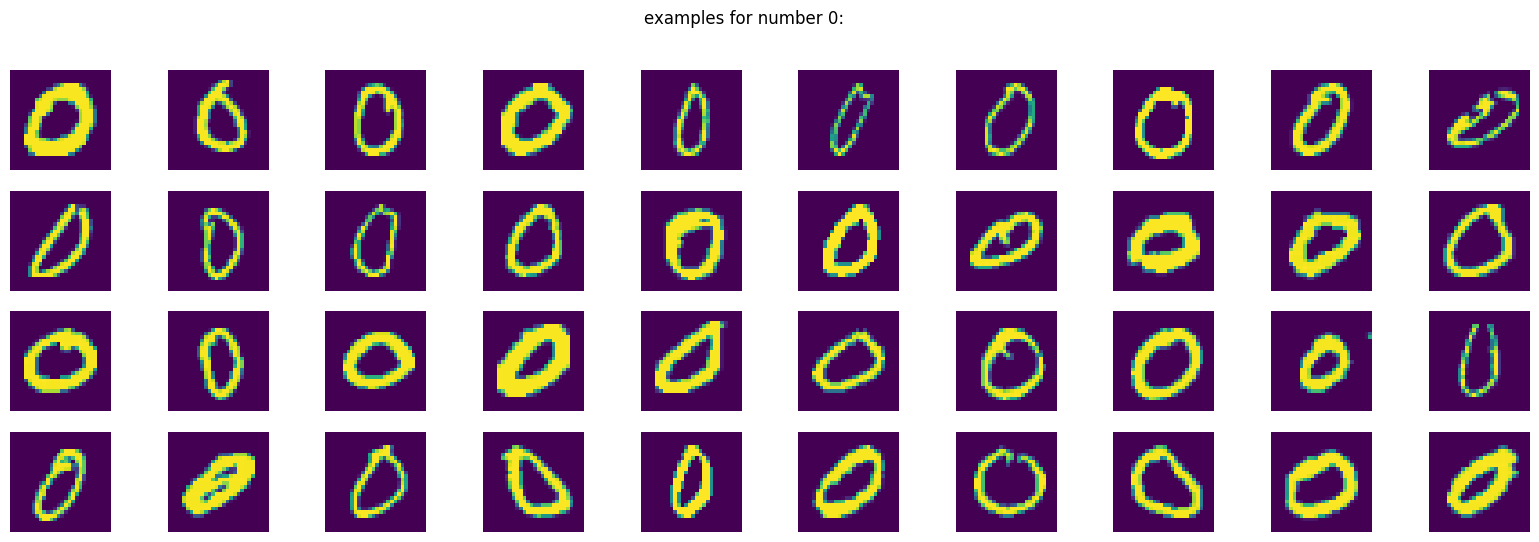

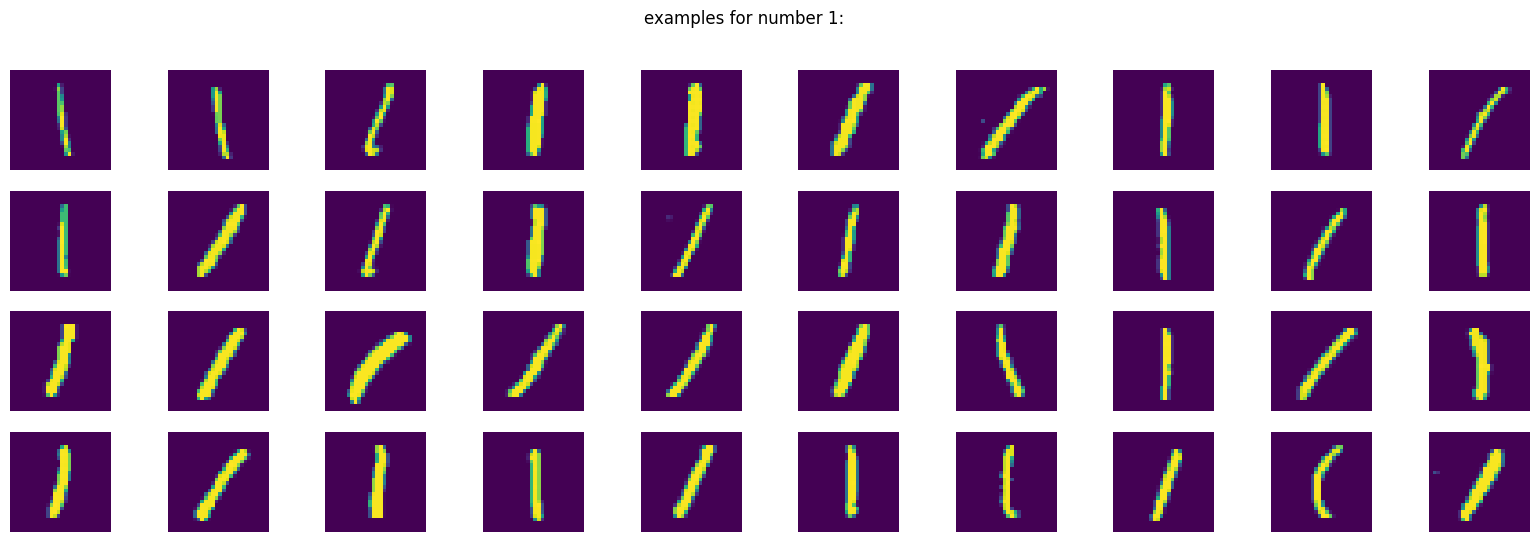

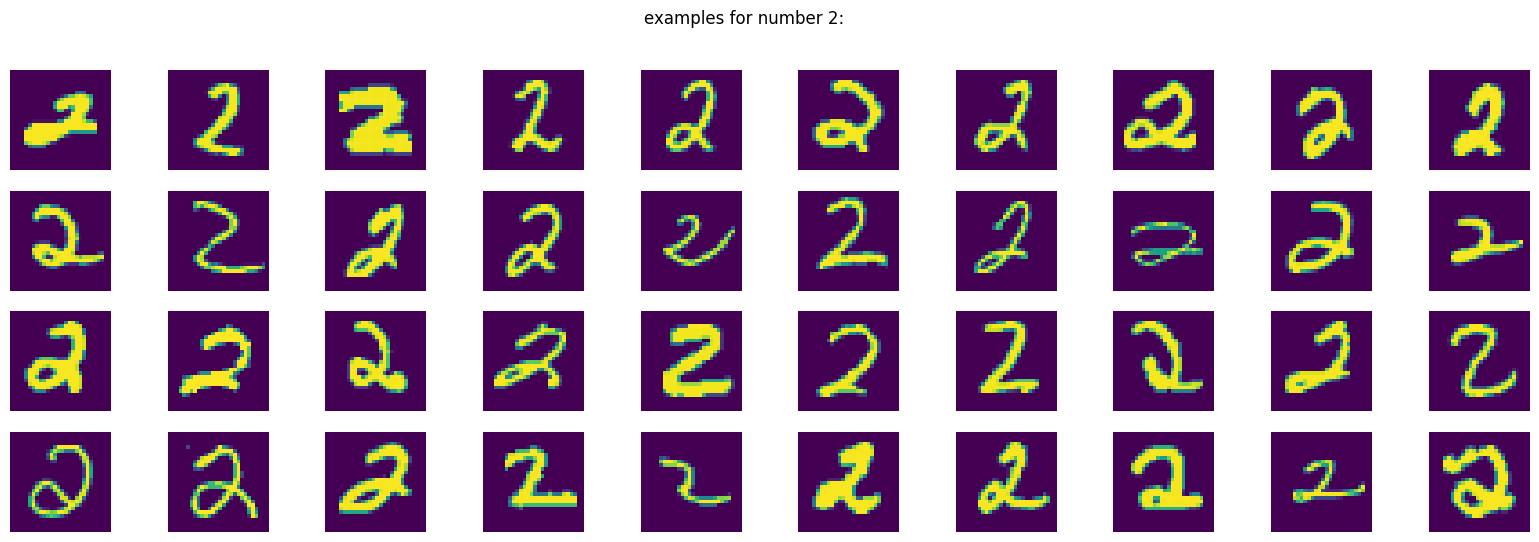

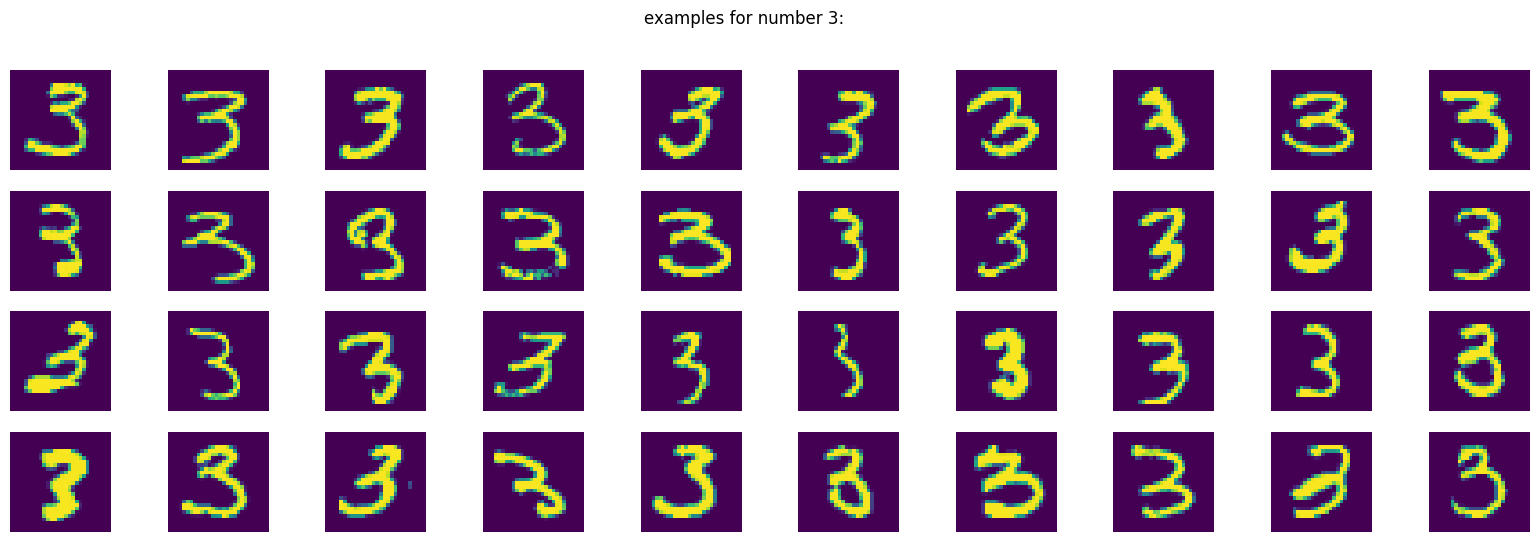

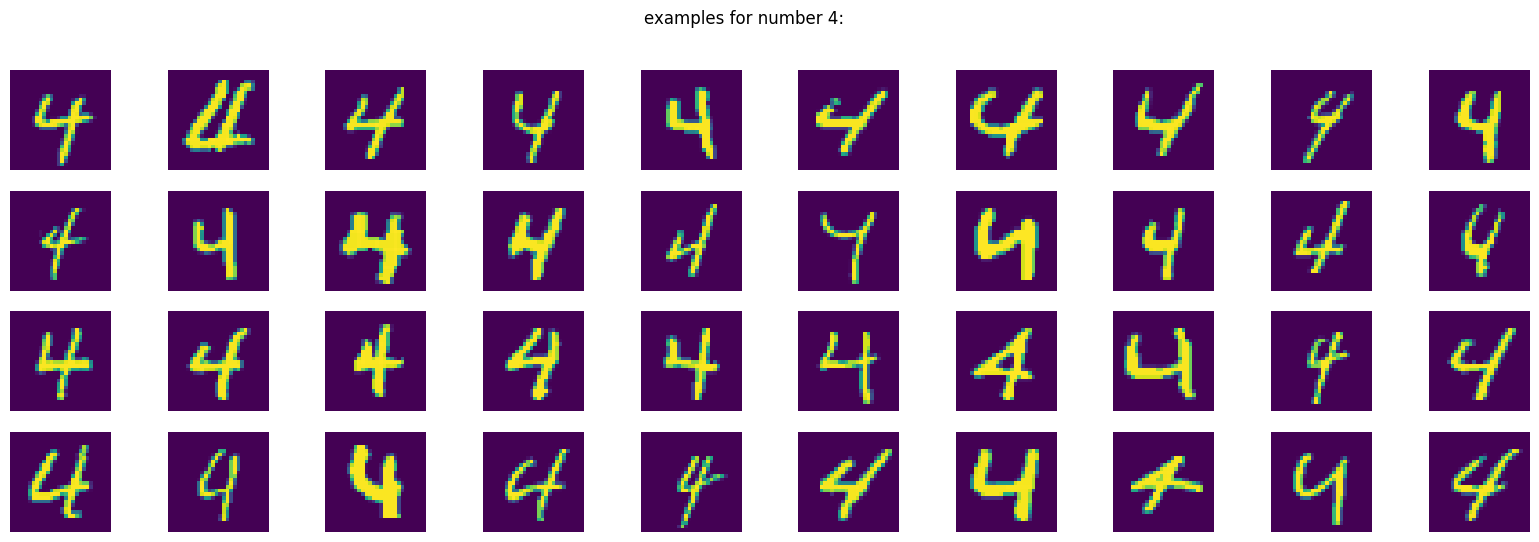

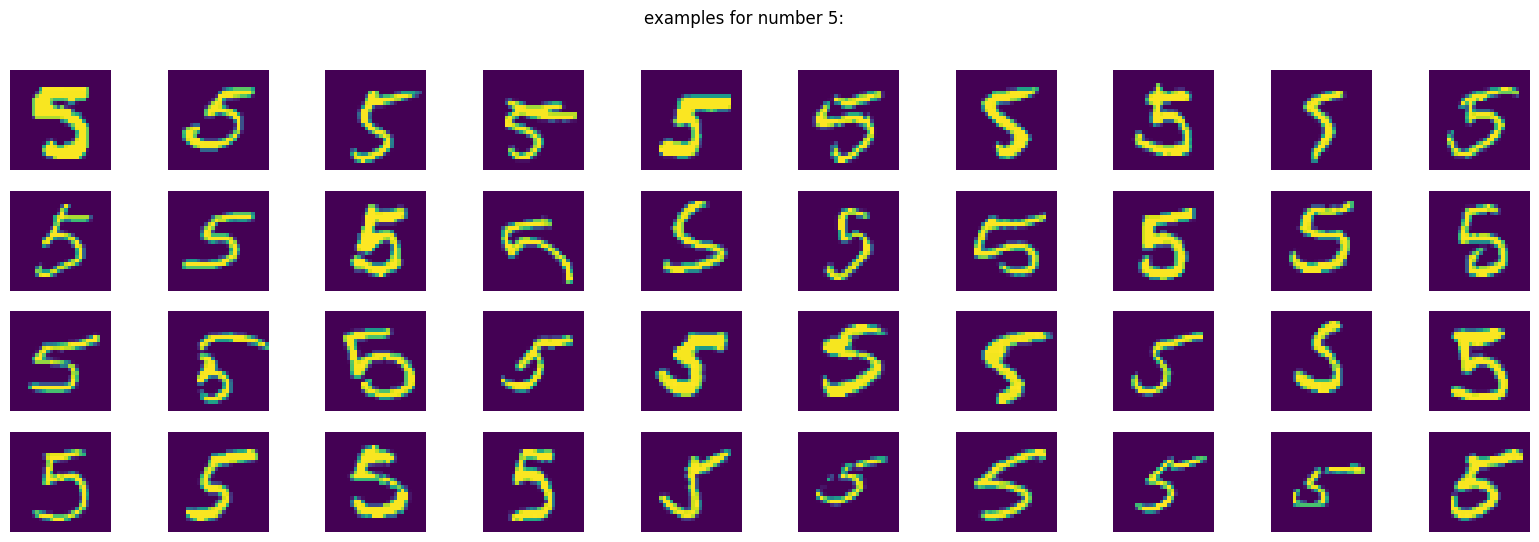

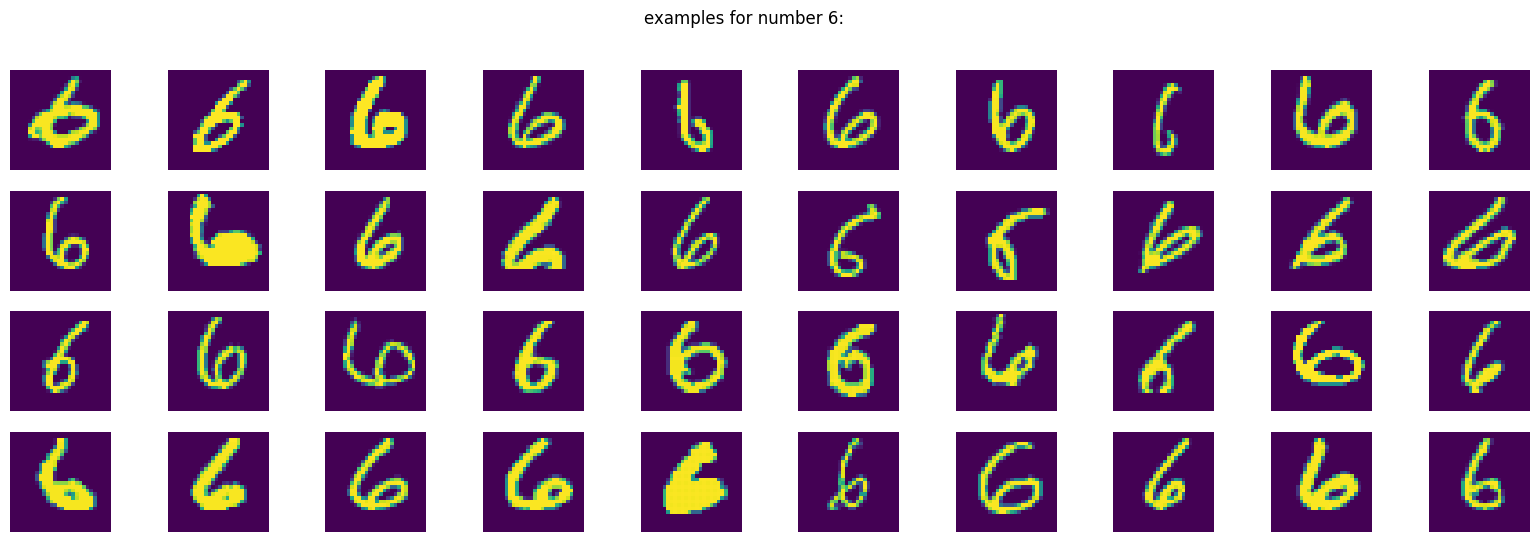

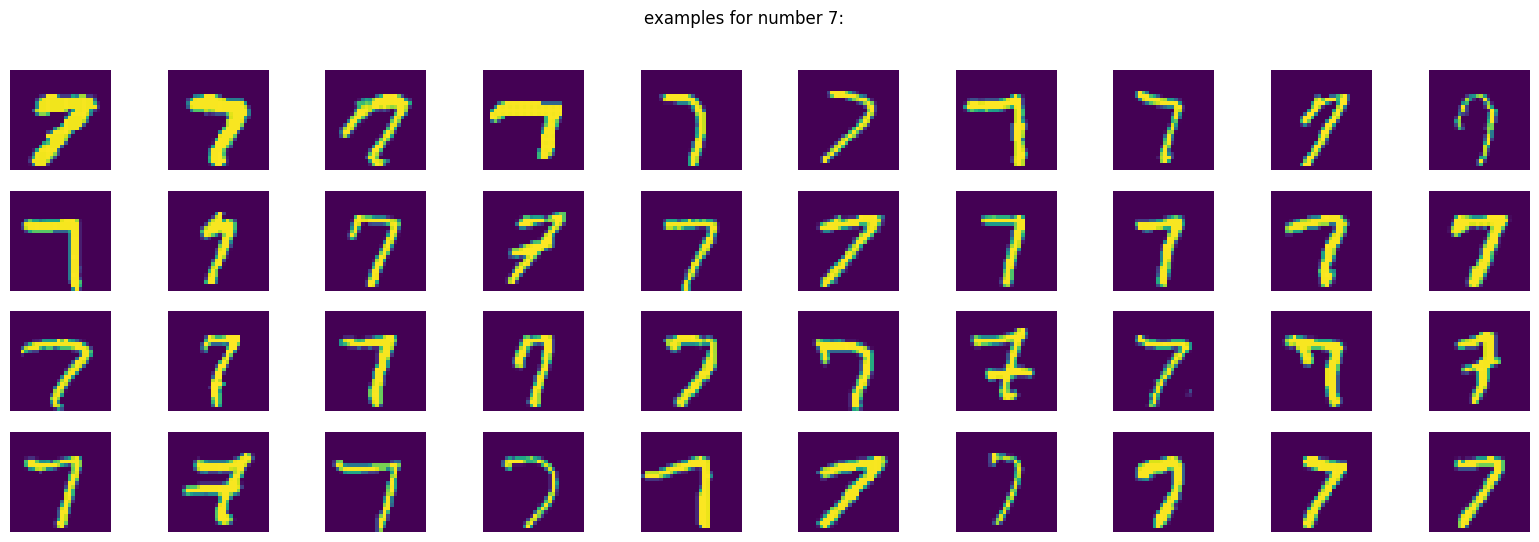

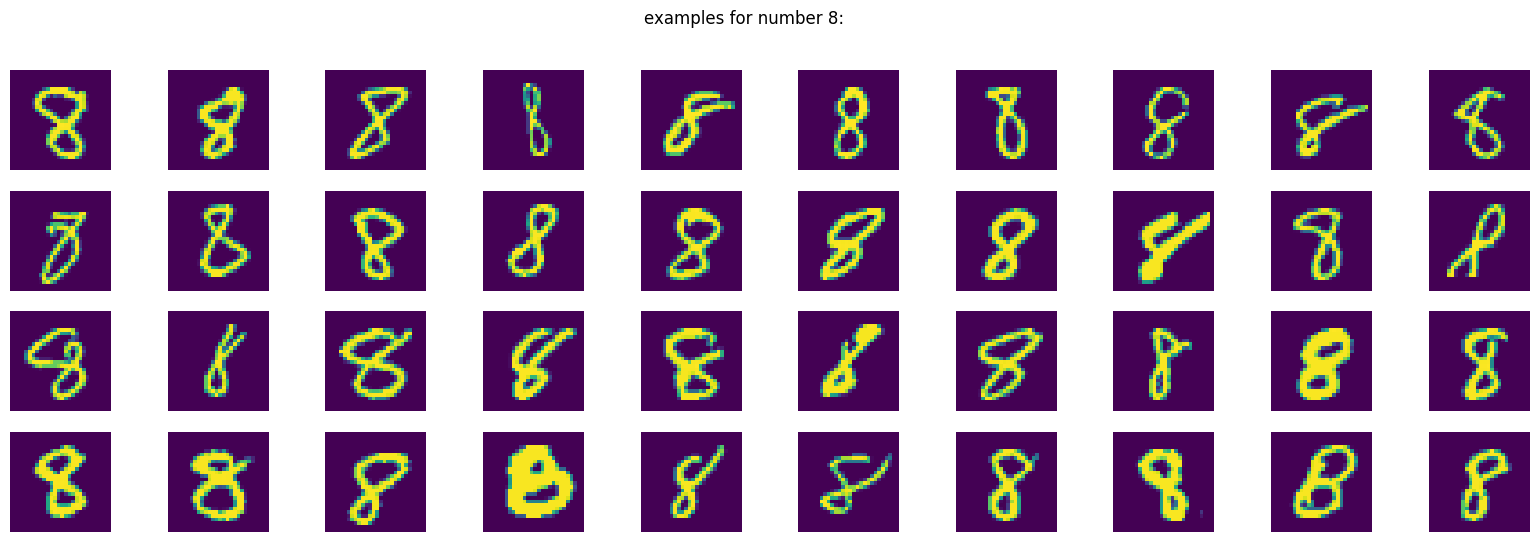

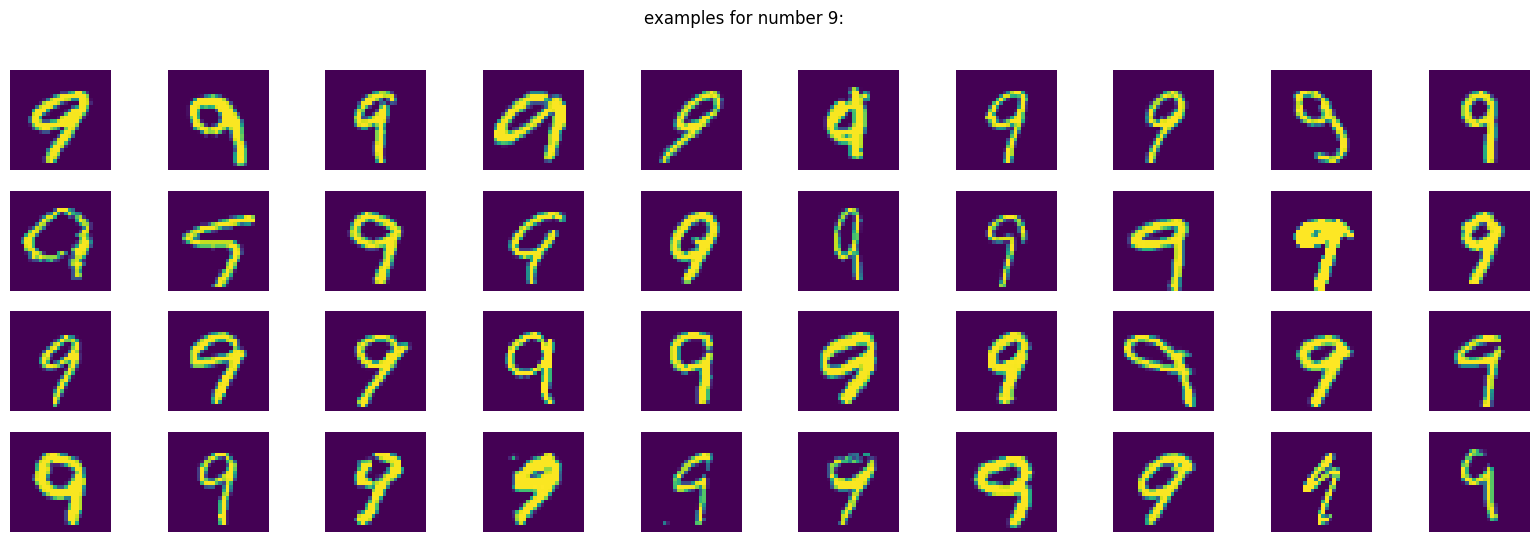

In [130]:
plot_samples(x_train, y_train)

In [131]:
x_train = x_train / 255.0    #normalizing the data
x_test = x_test / 255.0

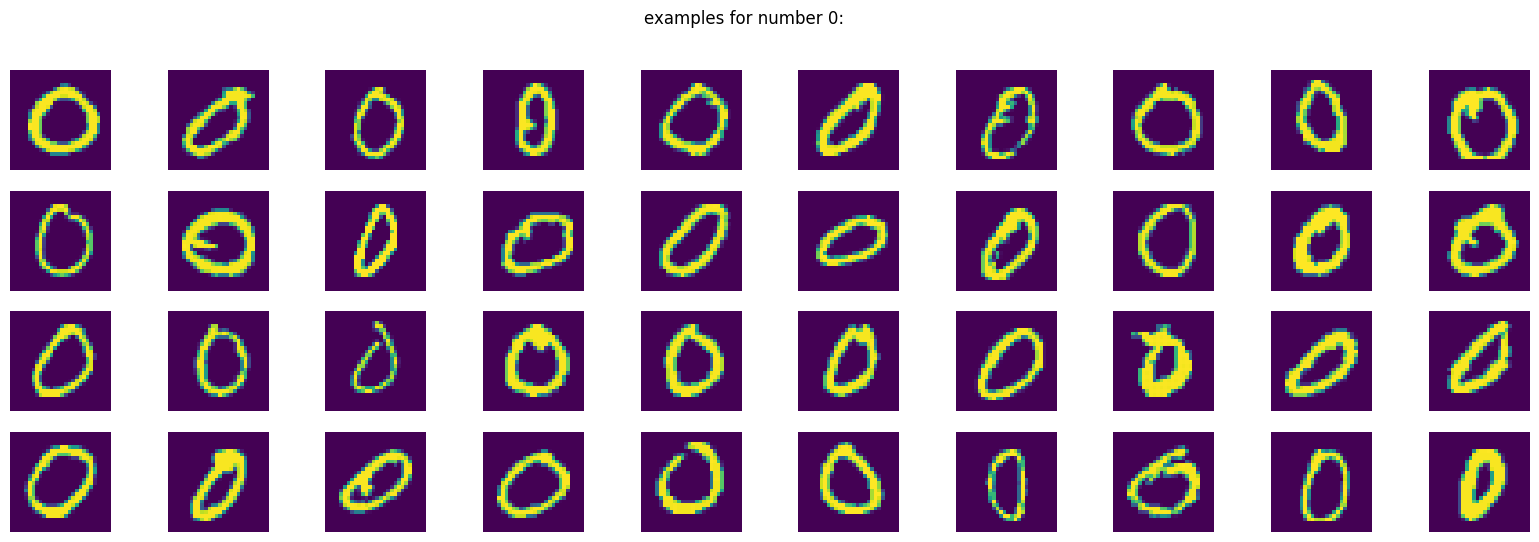

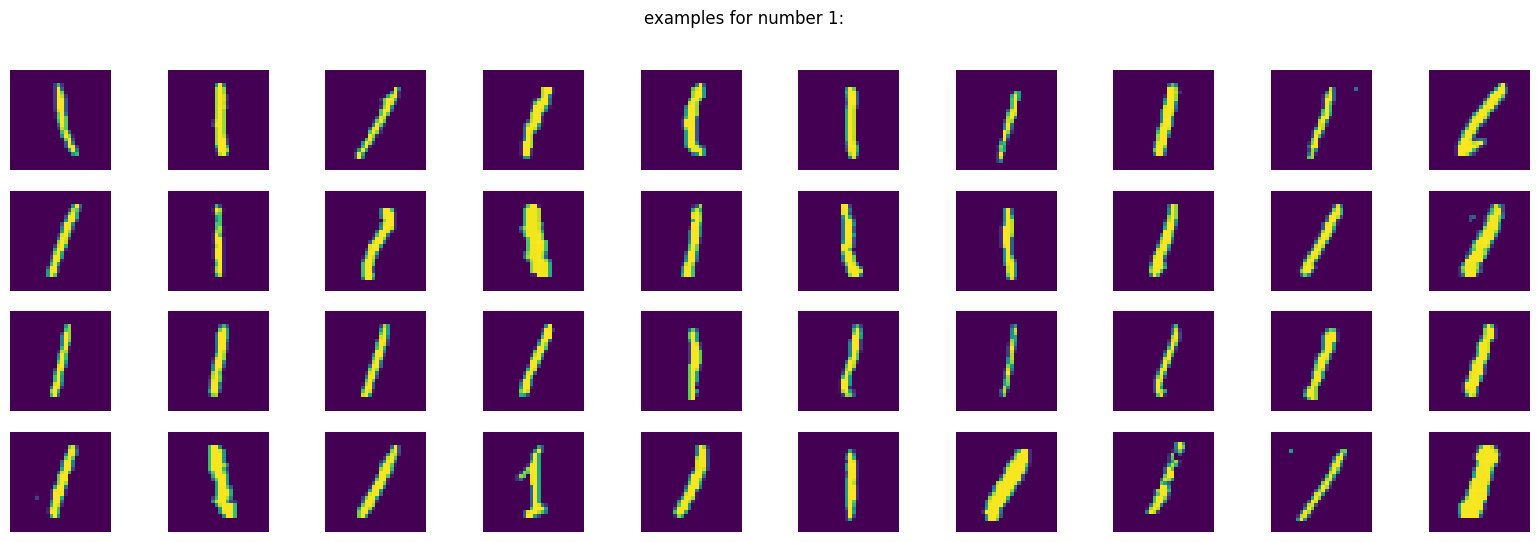

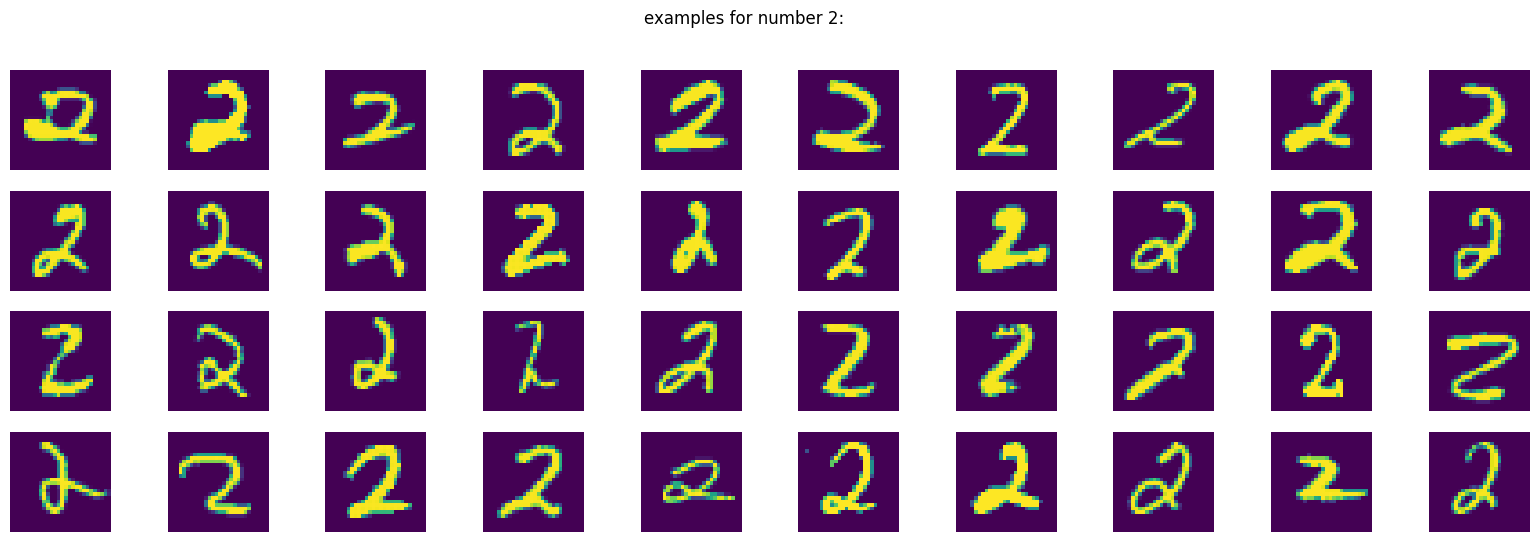

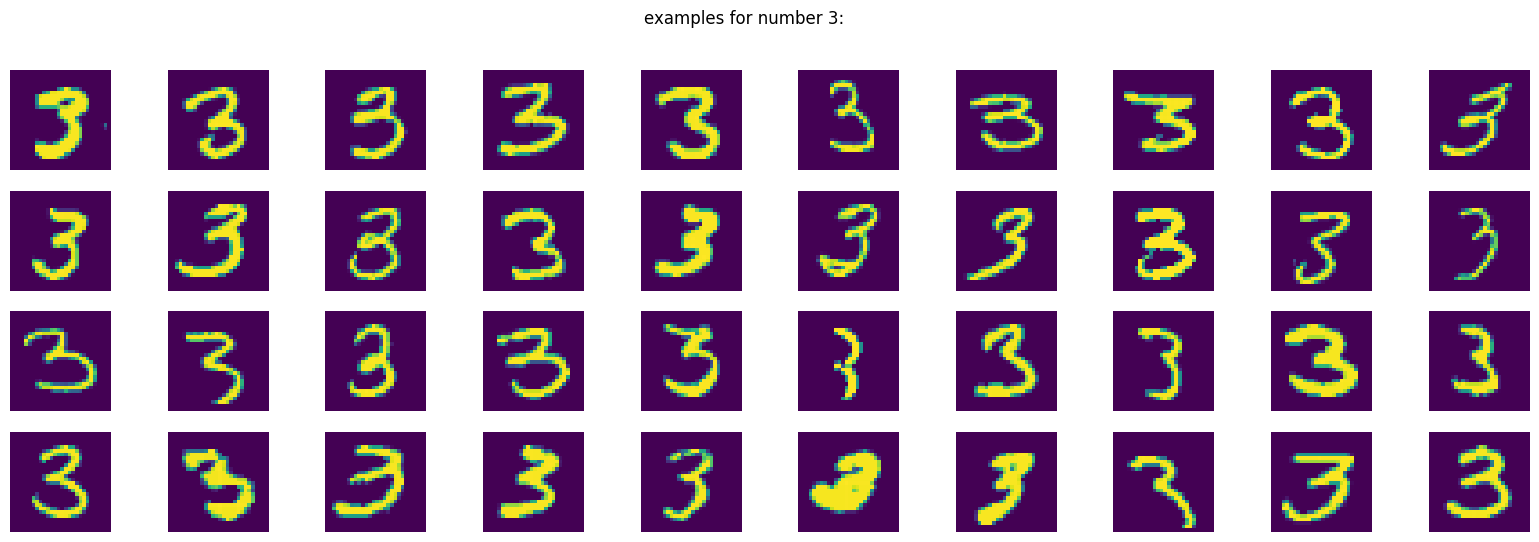

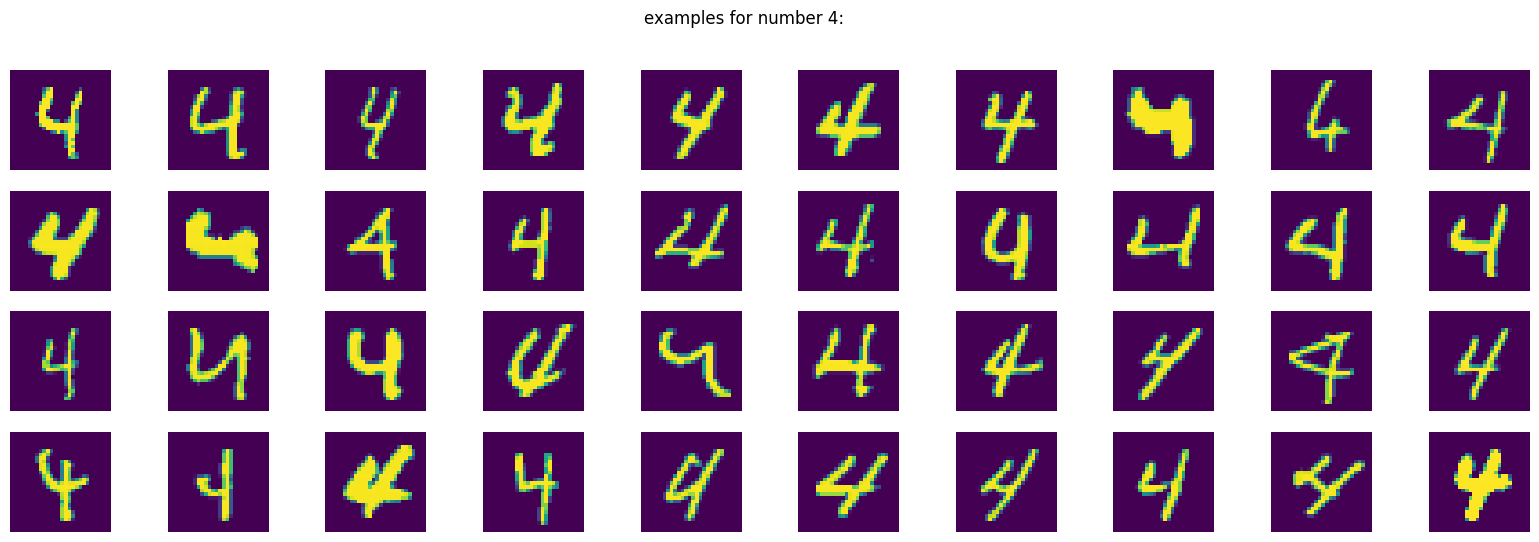

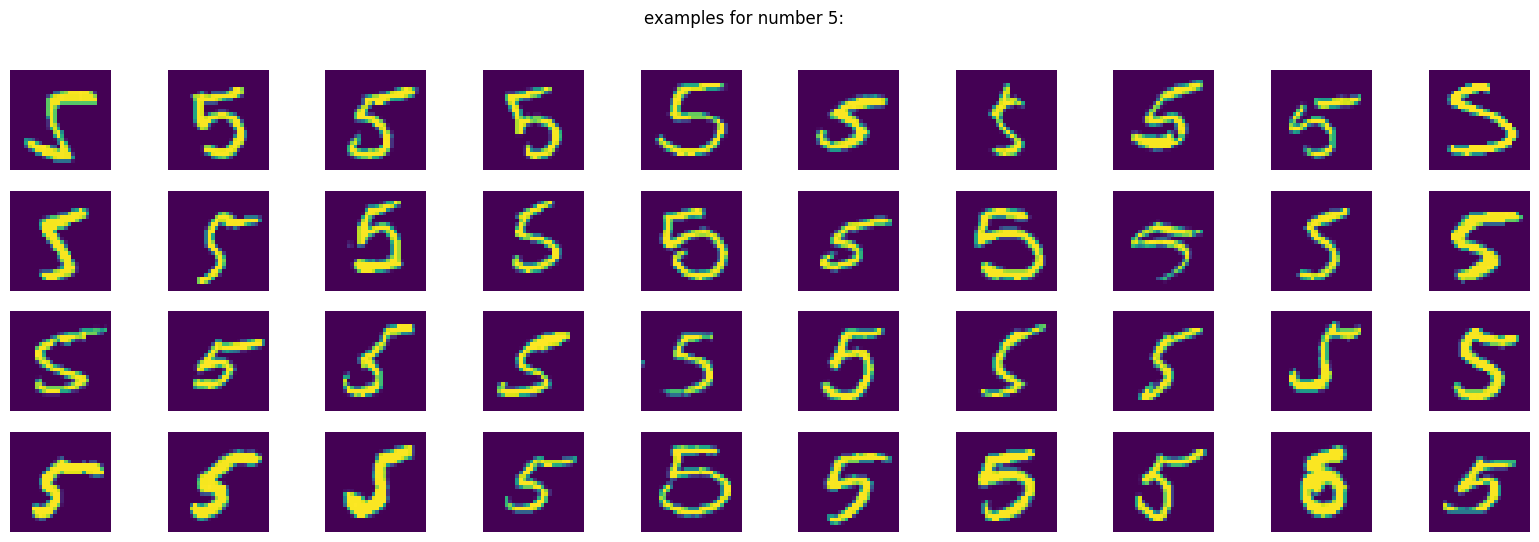

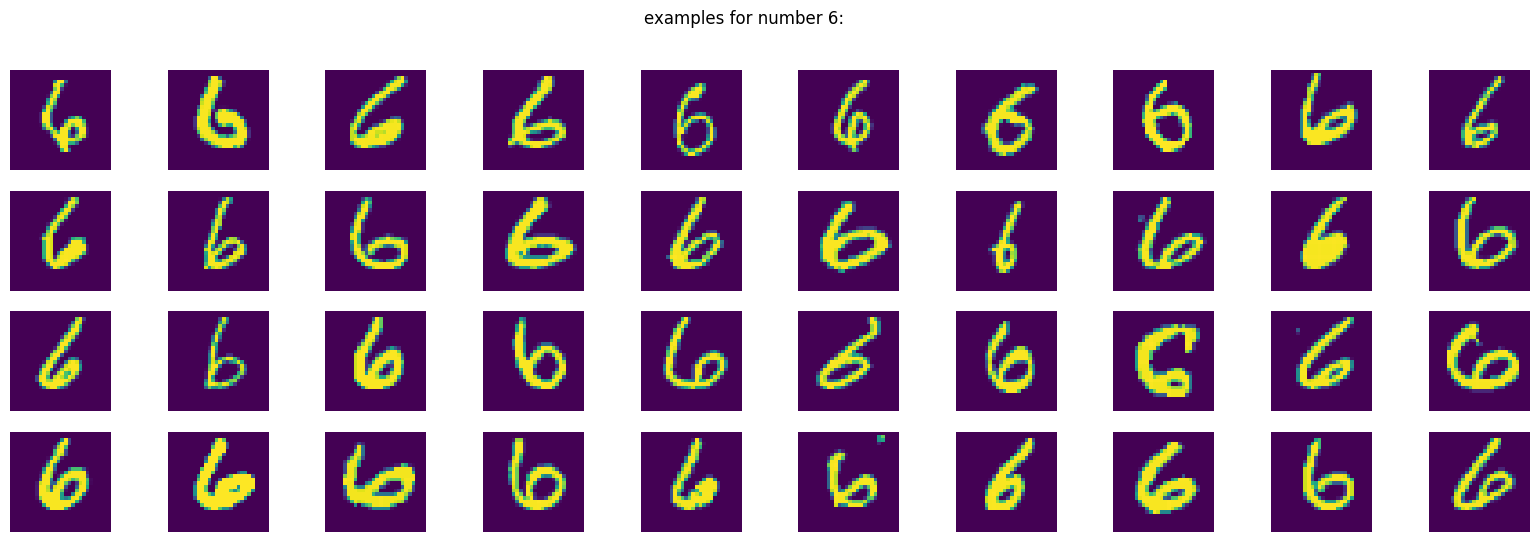

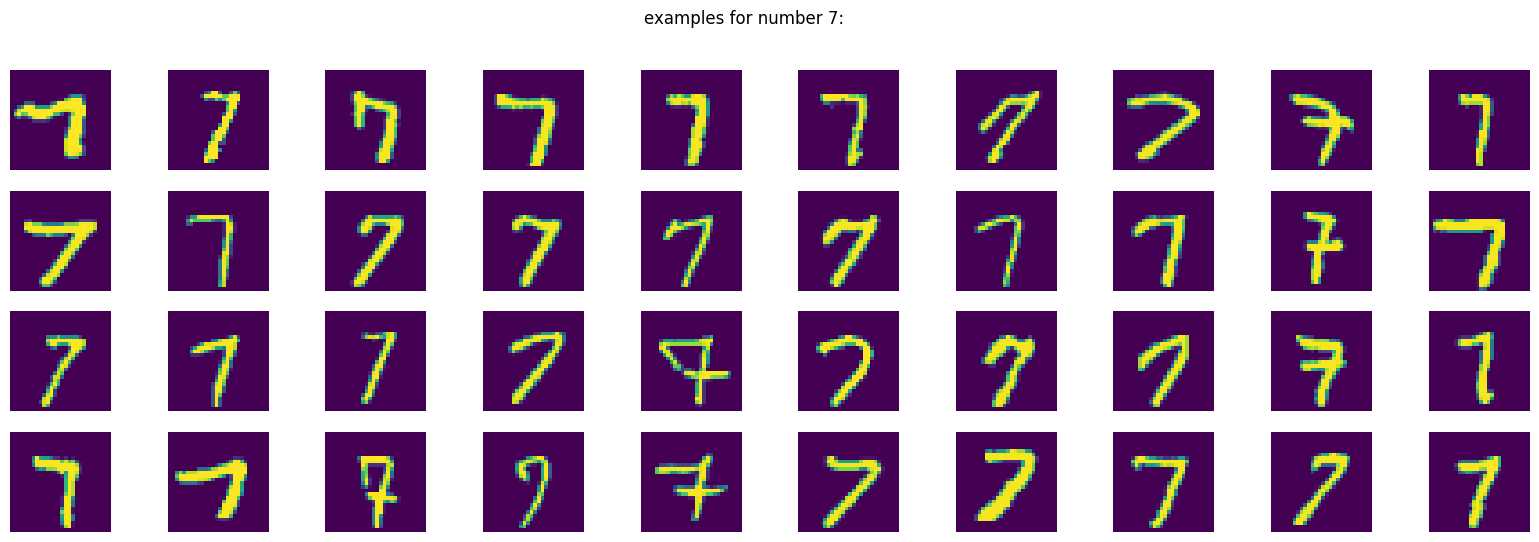

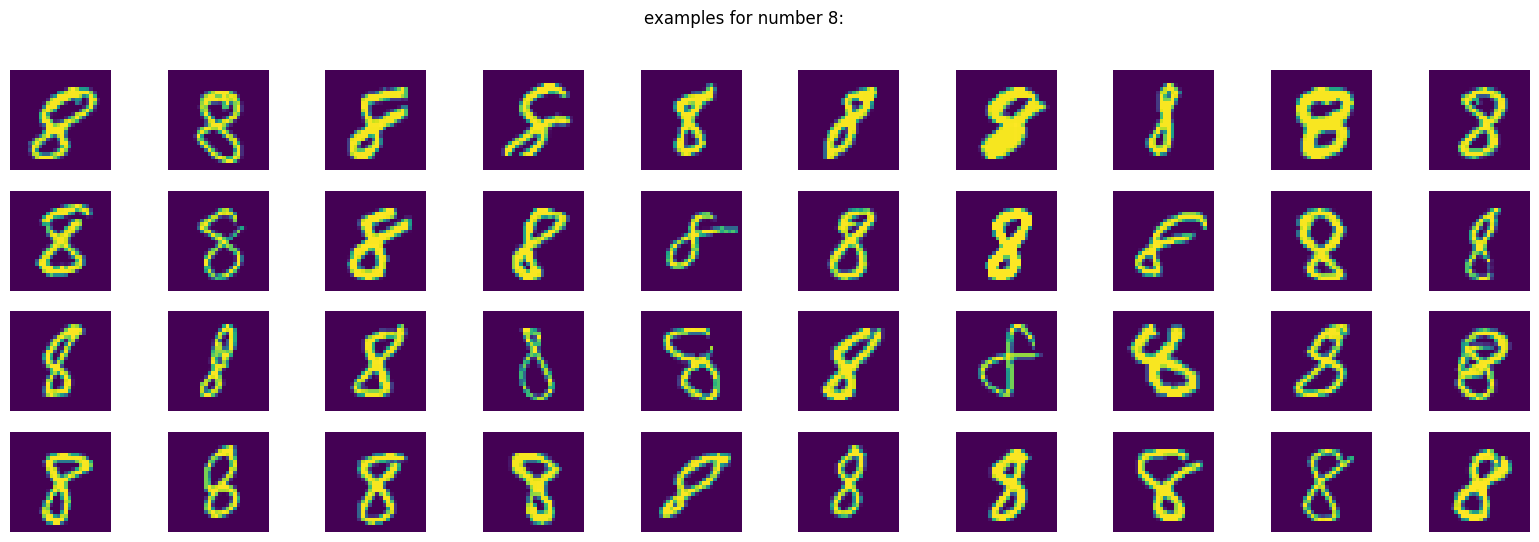

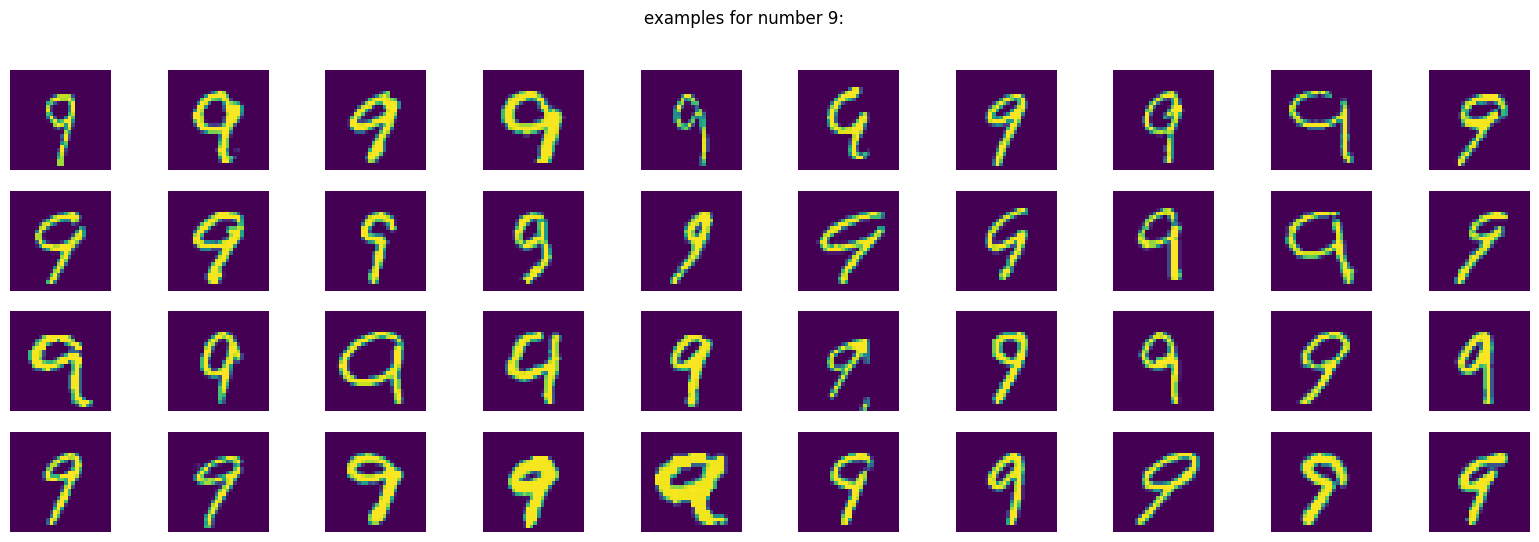

In [132]:
plot_samples(x_train, y_train)

In [133]:
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("New x_train shape:", x_train.shape)
print("New x_test shape:", x_test.shape)

New x_train shape: (60000, 28, 28, 1)
New x_test shape: (10000, 28, 28, 1)


# Baseline CNN Model

In [134]:
#building the first simple CNN

def create_simple_model():
    inputs = keras.layers.Input(shape=(28, 28, 1), name="input_image")

    x = keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        name="conv_1"
    )(inputs)

    x = keras.layers.MaxPooling2D(
        pool_size=(3, 3),
        name="maxpool_1"
    )(x)

    x = keras.layers.Flatten(name="flatten")(x)

    x = keras.layers.Dense(
        64,
        activation="relu",
        name="dense_1"
    )(x)

    outputs = keras.layers.Dense(
        10,
        activation="softmax",
        name="output"
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="simple_cnn")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    model.summary()
    return model

In [135]:
tf.keras.backend.clear_session()

model1 = create_simple_model()


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_1 (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ maxpool_1 (MaxPooling2D)             │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │         131,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 132,106 (516.04 KB)

 Trainable params: 132,106 (516.04 KB)

 Non-trainable params: 0 (0.00 B)

## Train the baseline model

In [136]:
tf.keras.backend.clear_session()
model1 = create_simple_model()
model1.fit(
    x_train,
    y_train,
    batch_size=4,
    epochs=10,
    validation_split=0.2
)
model1.save("model_batch_4.keras")

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_1 (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ maxpool_1 (MaxPooling2D)             │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │         131,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 132,106 (516.04 KB)

 Trainable params: 132,106 (516.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.9554 - loss: 0.1461 - val_accuracy: 0.9800 - val_loss: 0.0711
Epoch 2/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.9828 - loss: 0.0562 - val_accuracy: 0.9838 - val_loss: 0.0579
Epoch 3/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.9893 - loss: 0.0343 - val_accuracy: 0.9847 - val_loss: 0.0616
Epoch 4/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.9925 - loss: 0.0238 - val_accuracy: 0.9850 - val_loss: 0.0669
Epoch 5/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - accuracy: 0.9943 - loss: 0.0167 - val_accuracy: 0.9868 - val_loss: 0.0645
Epoch 6/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.9953 - loss: 0.0141 - val_accuracy: 0.9843 - val_loss: 0.0840
Epoch 7/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.9963 - loss: 0.0113 - val_accuracy: 0.9863 - val_loss: 0.0789
Epoch 8/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 

# Batch Size experiment
## batch_size = 8

In [137]:
tf.keras.backend.clear_session()
model1 = create_simple_model()
model1.fit(
    x_train,
    y_train,
    batch_size=8,
    epochs=10,
    validation_split=0.2
)
model1.save("model_batch_8.keras")


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_1 (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ maxpool_1 (MaxPooling2D)             │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │         131,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 132,106 (516.04 KB)

 Trainable params: 132,106 (516.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.9505 - loss: 0.1656 - val_accuracy: 0.9782 - val_loss: 0.0712
Epoch 2/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9811 - loss: 0.0625 - val_accuracy: 0.9834 - val_loss: 0.0565
Epoch 3/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9880 - loss: 0.0386 - val_accuracy: 0.9836 - val_loss: 0.0571
Epoch 4/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9921 - loss: 0.0256 - val_accuracy: 0.9857 - val_loss: 0.0572
Epoch 5/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9946 - loss: 0.0172 - val_accuracy: 0.9858 - val_loss: 0.0584
Epoch 6/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9952 - loss: 0.0140 - val_accuracy: 0.9860 - val_loss: 0.0567
Epoch 7/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9963 - loss: 0.0105 - val_accuracy: 0.9867 - val_loss: 0.0606
Epoch 8/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.9966 - loss: 0

## batch_size = 16

In [138]:
tf.keras.backend.clear_session()
model1 = create_simple_model()
model1.fit(
    x_train,
    y_train,
    batch_size=16,
    epochs=10,
    validation_split=0.2
)
model1.save("model_batch_16.keras")


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_1 (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ maxpool_1 (MaxPooling2D)             │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │         131,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 132,106 (516.04 KB)

 Trainable params: 132,106 (516.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9437 - loss: 0.1924 - val_accuracy: 0.9738 - val_loss: 0.0923
Epoch 2/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9794 - loss: 0.0688 - val_accuracy: 0.9832 - val_loss: 0.0569
Epoch 3/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9860 - loss: 0.0464 - val_accuracy: 0.9846 - val_loss: 0.0527
Epoch 4/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9901 - loss: 0.0326 - val_accuracy: 0.9847 - val_loss: 0.0544
Epoch 5/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9933 - loss: 0.0235 - val_accuracy: 0.9838 - val_loss: 0.0614
Epoch 6/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9946 - loss: 0.0178 - val_accuracy: 0.9855 - val_loss: 0.0588
Epoch 7/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9961 - loss: 0.0135 - val_accuracy: 0.9857 - val_loss: 0.0577
Epoch 8/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9965 - loss: 0.0106 - 

## batch_size = 32

In [139]:
tf.keras.backend.clear_session()
model1 = create_simple_model()
model1.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.2
)
model1.save("model_batch_32.keras")


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_1 (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ maxpool_1 (MaxPooling2D)             │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │         131,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 132,106 (516.04 KB)

 Trainable params: 132,106 (516.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9374 - loss: 0.2168 - val_accuracy: 0.9775 - val_loss: 0.0815
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9779 - loss: 0.0726 - val_accuracy: 0.9815 - val_loss: 0.0648
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9846 - loss: 0.0521 - val_accuracy: 0.9822 - val_loss: 0.0620
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9879 - loss: 0.0402 - val_accuracy: 0.9812 - val_loss: 0.0649
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9909 - loss: 0.0303 - val_accuracy: 0.9821 - val_loss: 0.0654
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9933 - loss: 0.0228 - val_accuracy: 0.9830 - val_loss: 0.0646
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9952 - loss: 0.0178 - val_accuracy: 0.9838 - val_loss: 0.0624
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9962 - loss: 0.0131 - 

## batch_size=64

In [140]:
tf.keras.backend.clear_session()
model1 = create_simple_model()
model1.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)
model1.save("model_batch_64.keras")


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_1 (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ maxpool_1 (MaxPooling2D)             │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │         131,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 132,106 (516.04 KB)

 Trainable params: 132,106 (516.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9213 - loss: 0.2768 - val_accuracy: 0.9722 - val_loss: 0.1004
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9738 - loss: 0.0892 - val_accuracy: 0.9786 - val_loss: 0.0721
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9804 - loss: 0.0650 - val_accuracy: 0.9821 - val_loss: 0.0622
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9841 - loss: 0.0522 - val_accuracy: 0.9827 - val_loss: 0.0567
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9873 - loss: 0.0427 - val_accuracy: 0.9842 - val_loss: 0.0534
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9895 - loss: 0.0353 - val_accuracy: 0.9851 - val_loss: 0.0523
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9918 - loss: 0.0291 - val_accuracy: 0.9866 - val_loss: 0.0510
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9931 - loss: 0.0236 - val_accuracy: 0.

## batch_size = 128

In [141]:
tf.keras.backend.clear_session()
model1 = create_simple_model()
model1.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.2
)
model1.save("model_batch_128.keras")


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_1 (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ maxpool_1 (MaxPooling2D)             │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │         131,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 132,106 (516.04 KB)

 Trainable params: 132,106 (516.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9074 - loss: 0.3449 - val_accuracy: 0.9665 - val_loss: 0.1210
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9693 - loss: 0.1032 - val_accuracy: 0.9765 - val_loss: 0.0810
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9775 - loss: 0.0744 - val_accuracy: 0.9803 - val_loss: 0.0686
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9816 - loss: 0.0600 - val_accuracy: 0.9822 - val_loss: 0.0625
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9847 - loss: 0.0506 - val_accuracy: 0.9831 - val_loss: 0.0599
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9868 - loss: 0.0432 - val_accuracy: 0.9836 - val_loss: 0.0575
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9892 - loss: 0.0366 - val_accuracy: 0.9842 - val_loss: 0.0565
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9907 - loss: 0.0313 - val_accuracy: 0.

### train final model

In [142]:
tf.keras.backend.clear_session()
model1 = create_simple_model()

history1 = model1.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)
model1.save('baseline_model.keras')
#Evaluate on test data
print("Performance on test data:")
test_loss, test_acc = model1.evaluate(x_test, y_test)

baseline_test_acc = test_acc

print("Baseline test accuracy:", baseline_test_acc)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_1 (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ maxpool_1 (MaxPooling2D)             │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │         131,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 132,106 (516.04 KB)

 Trainable params: 132,106 (516.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9214 - loss: 0.2784 - val_accuracy: 0.9725 - val_loss: 0.1013
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9734 - loss: 0.0888 - val_accuracy: 0.9787 - val_loss: 0.0721
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9808 - loss: 0.0641 - val_accuracy: 0.9818 - val_loss: 0.0618
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9848 - loss: 0.0504 - val_accuracy: 0.9828 - val_loss: 0.0578
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9877 - loss: 0.0405 - val_accuracy: 0.9838 - val_loss: 0.0547
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9901 - loss: 0.0330 - val_accuracy: 0.9854 - val_loss: 0.0532
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9923 - loss: 0.0270 - val_accuracy: 0.9858 - val_loss: 0.0516
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9937 - loss: 0.0221 - val_accuracy: 0.

## looking at validation behavior (ploting training and validation accuracy)

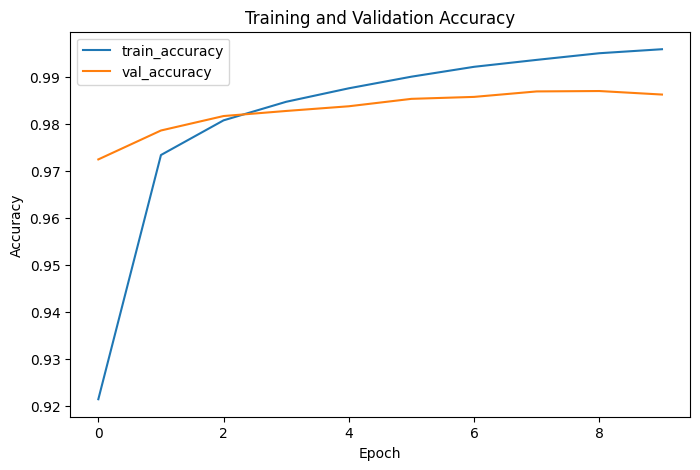

In [143]:
plt.figure(figsize=(8, 5))
plt.plot(history1.history["accuracy"], label="train_accuracy")
plt.plot(history1.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.savefig("accuracy_plot.png")
plt.show()

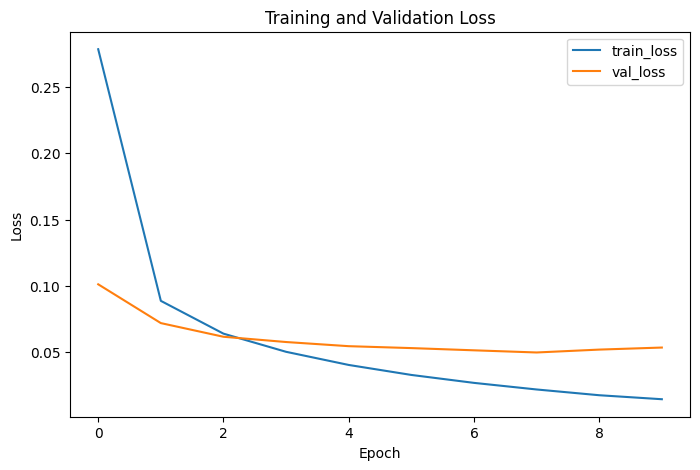

In [144]:
#(ploting training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history1.history["loss"], label="train_loss")
plt.plot(history1.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.savefig("loss_plot.png")
plt.show()

## Error Analysis
#### Check wrong predictions on training data

In [145]:
### predict number in picture
pred_train = model1.predict(x_train)

### identify the false categorized numbers 
wrong = [i for i in range(len(pred_train)) if pred_train[i].argmax() != y_train[i]]
print("number of wrong numbers:", len(wrong),".",
      " That is ", len(wrong)/len(pred_train)*100, "% of the data.")

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
number of wrong numbers: 356 .  That is  0.5933333333333333 % of the data.


#### plot the false categorized numbers

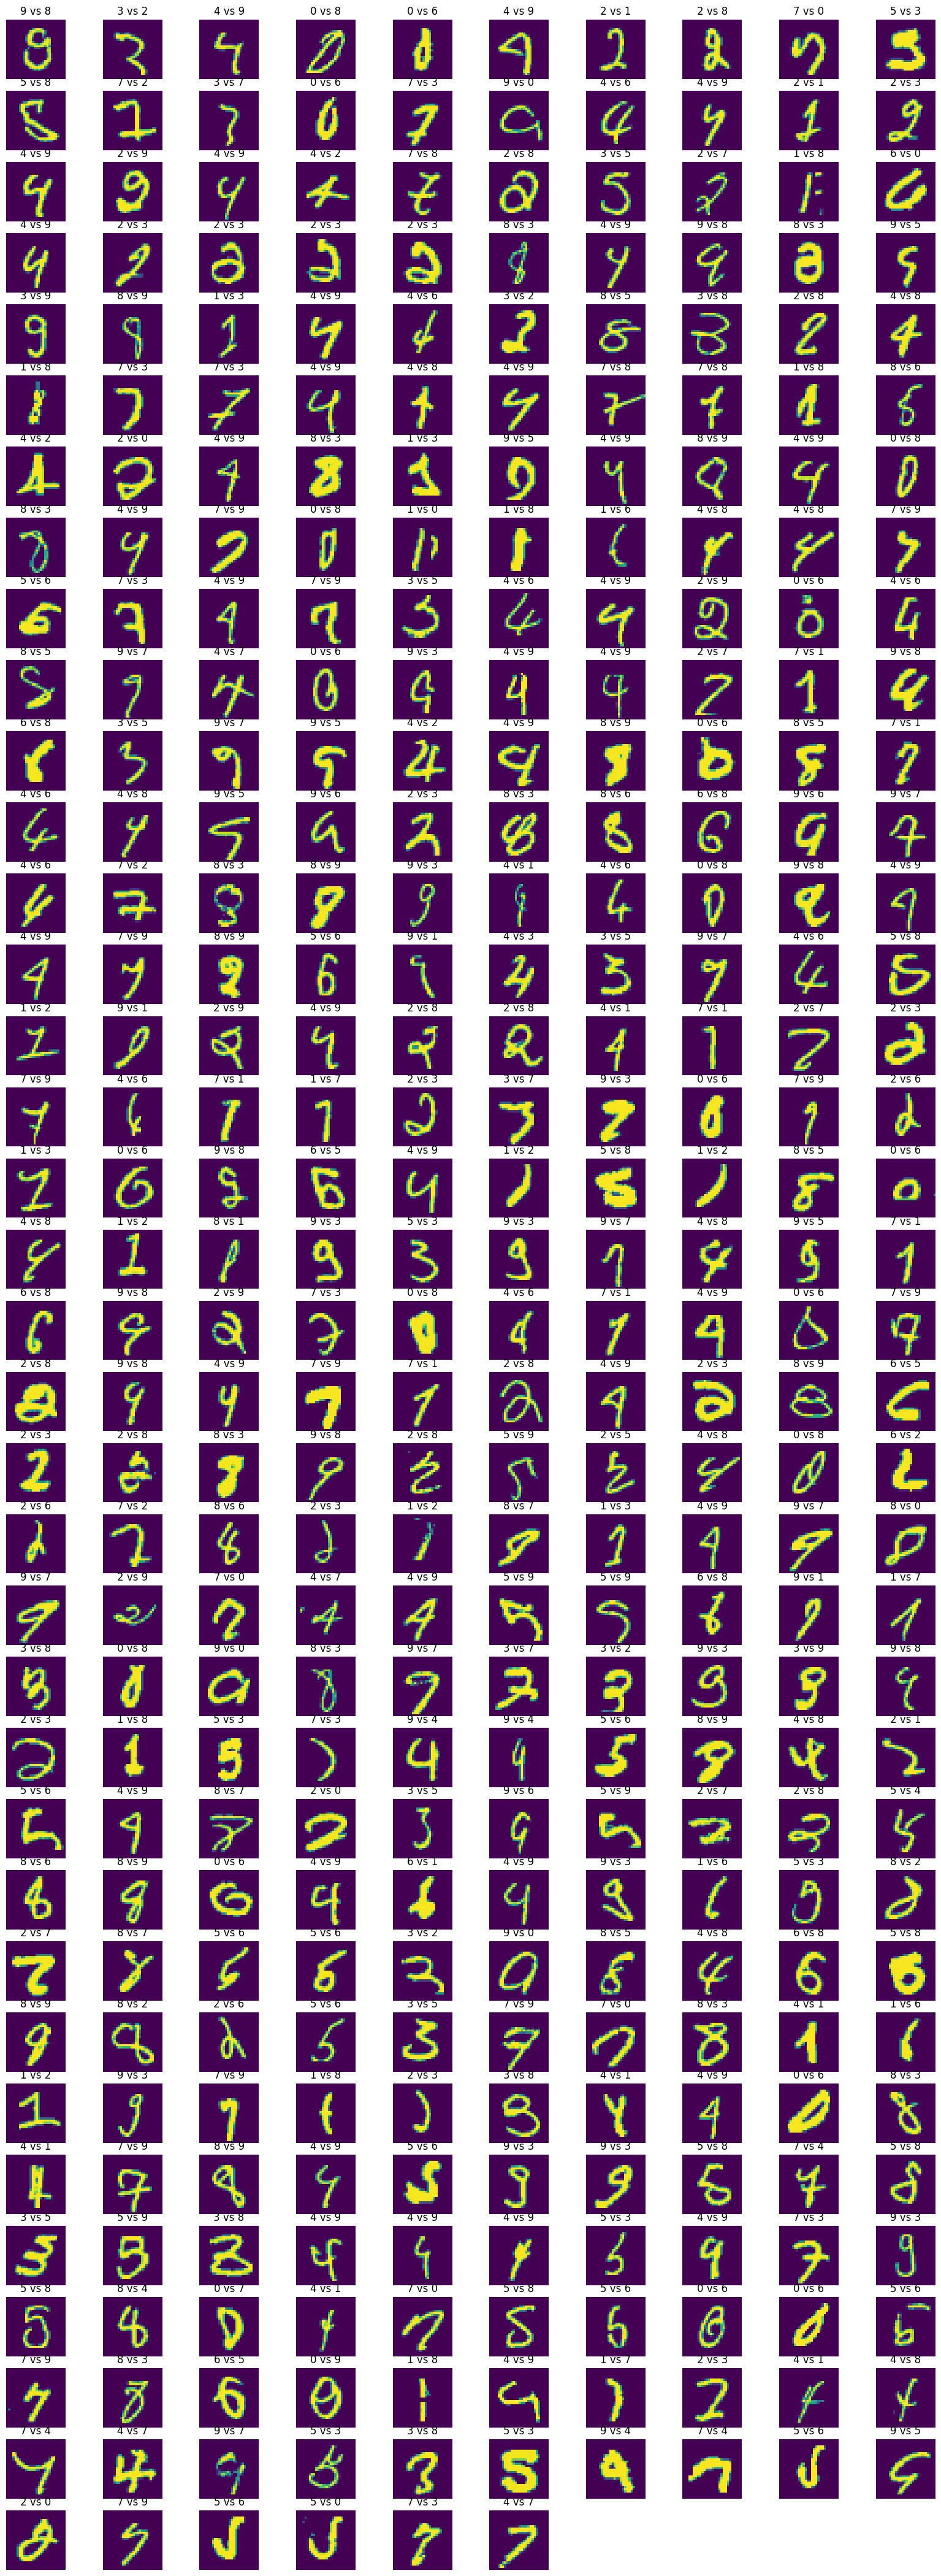

In [146]:
nsub = int(np.ceil(len(wrong)/10))
fig = plt.figure(figsize=(20, nsub*1.5))

nplt = 1
for index in wrong:
    ax = fig.add_subplot(nsub,10,nplt)
    ax.axis('off')
    ax.set_title(str(y_train[index])+' vs '+ str(pred_train[index].argmax()))
    plt.imshow(x_train[index])
    nplt += 1

#### Check wrong predictions on testing data

In [147]:
### predict number in picture
pred_test = model1.predict(x_test)

### identify the false categorized numbers 
wrong = [i for i in range(len(pred_test)) if pred_test[i].argmax() != y_test[i]]
print("number of wrong numbers:", len(wrong),".", 
      " That is ", len(wrong)/len(pred_test)*100, "% of the data.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
number of wrong numbers: 149 .  That is  1.49 % of the data.


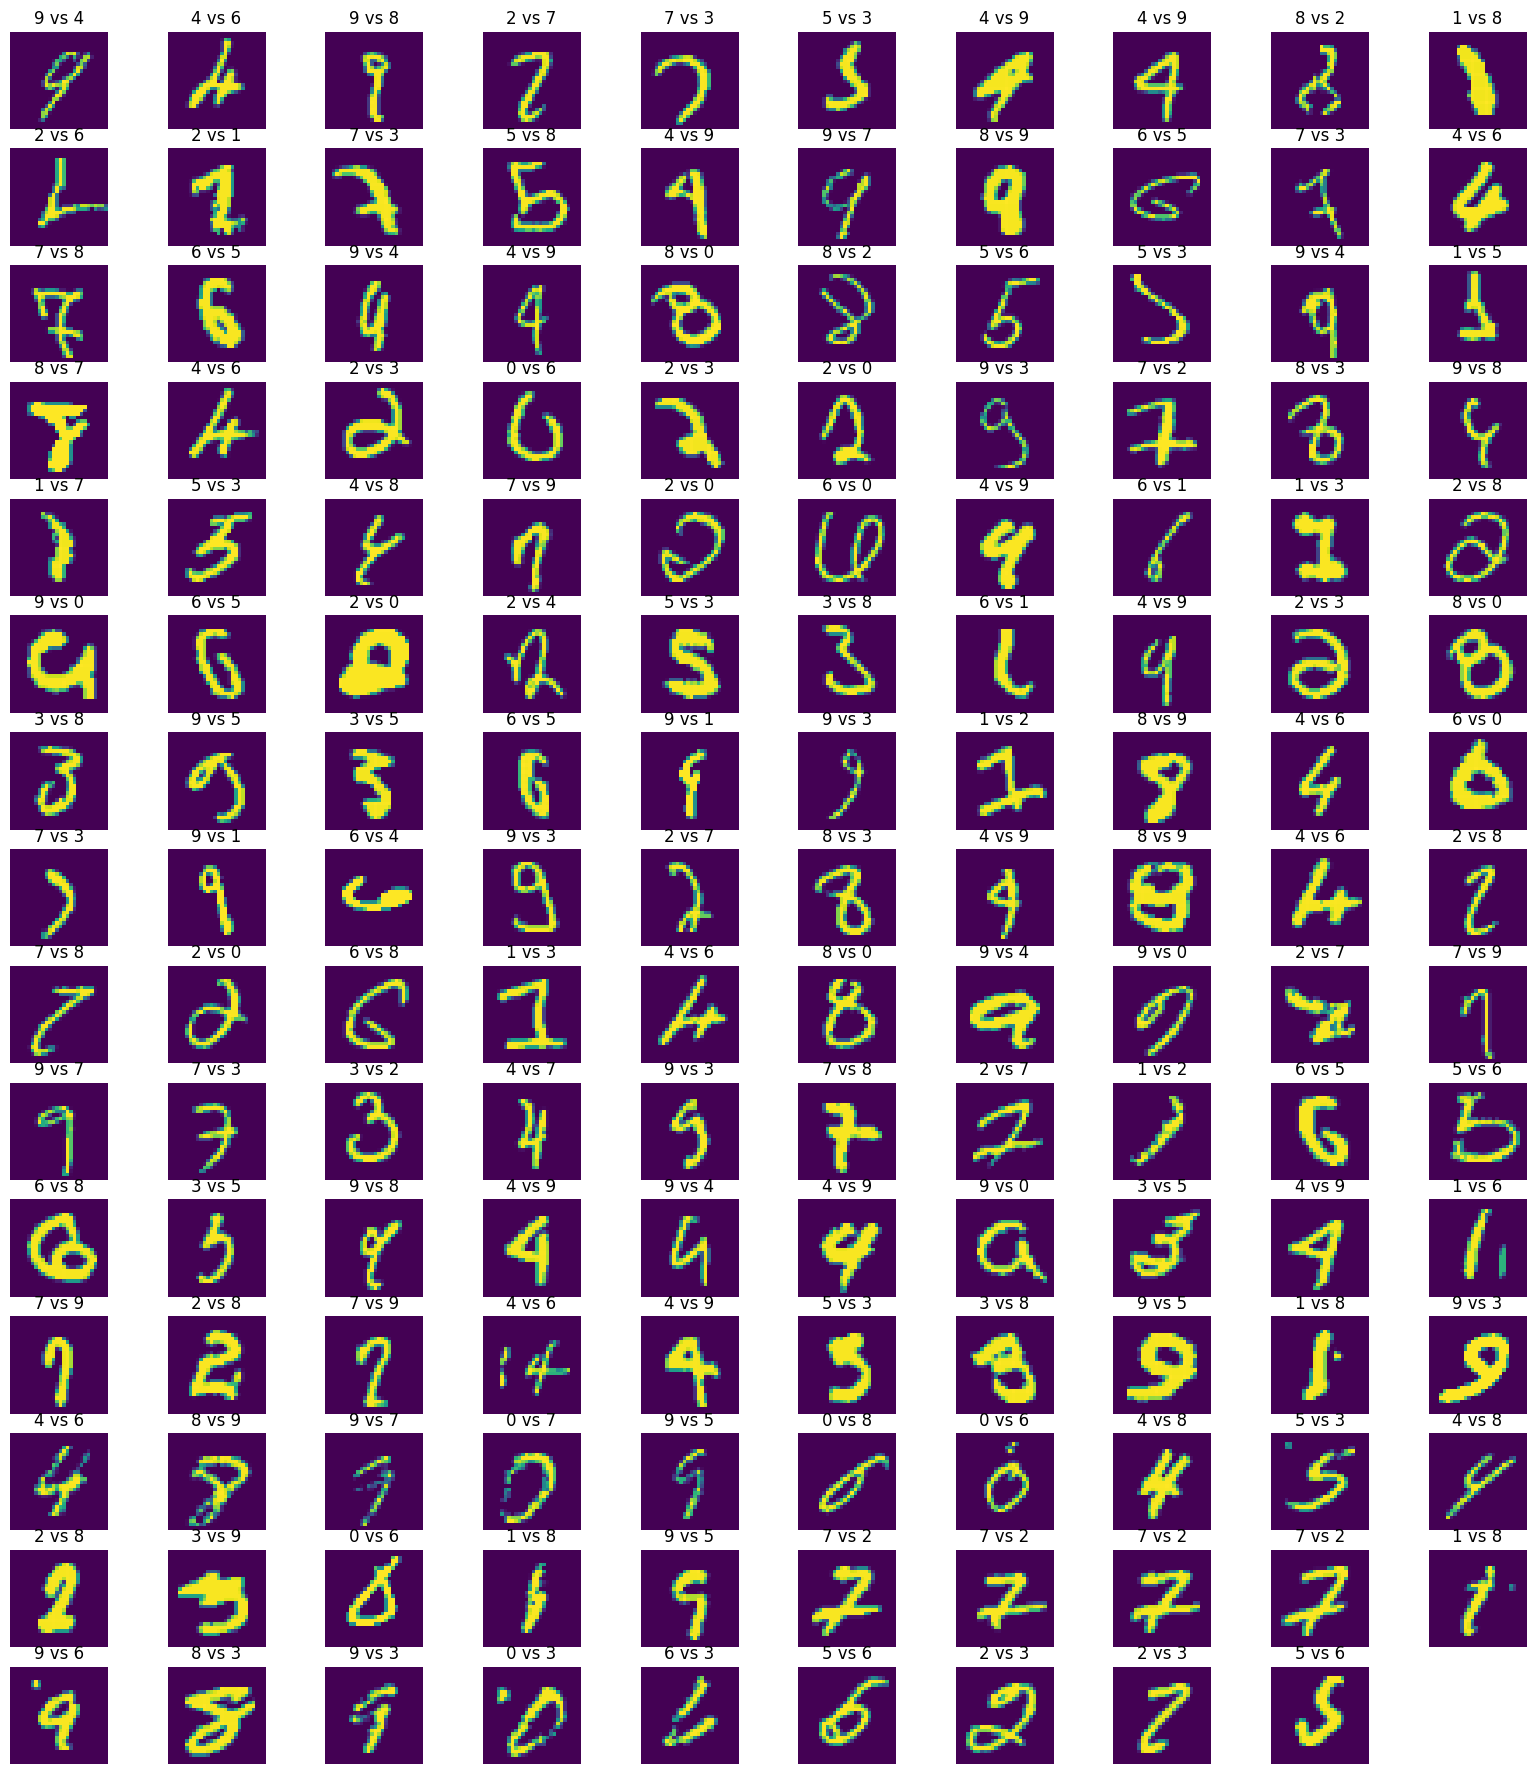

In [148]:
nsub = int(np.ceil(len(wrong)/10))
fig = plt.figure(figsize=(20, nsub*1.5))

nplt = 1
for index in wrong:
    ax = fig.add_subplot(nsub,10,nplt)
    ax.axis('off')
    ax.set_title(str(y_test[index]) + ' vs ' + str(pred_test[index].argmax()))
    plt.imshow(x_test[index])
    nplt += 1

# Architecture Experiments 
### varying the number of convolution filters

In [149]:
def create_filter_model(filters=32, pool_size=(3, 3)):      ###########2.1 Create a flexible model function
    inputs = keras.layers.Input(shape=(28, 28, 1), name="input_image")

    x = keras.layers.Conv2D(
        filters=filters,
        kernel_size=(3, 3),
        activation="relu",
        name="conv_1"
    )(inputs)

    x = keras.layers.MaxPooling2D(
        pool_size=pool_size,
        name="maxpool_1"
    )(x)

    x = keras.layers.Flatten(name="flatten")(x)

    x = keras.layers.Dense(
        64,
        activation="relu",
        name="dense_1"
    )(x)

    outputs = keras.layers.Dense(
        10,
        activation="softmax",
        name="output"
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name=f"cnn_{filters}_filters")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model
    inputs = keras.layers.Input(shape=(28, 28, 1), name="input_image")

    x = keras.layers.Conv2D(
        filters=filters,
        kernel_size=(3, 3),
        activation="relu",
        name="conv_1"
    )(inputs)

    x = keras.layers.MaxPooling2D(
        pool_size=pool_size,
        name="maxpool_1"
    )(x)

    x = keras.layers.Flatten(name="flatten")(x)

    x = keras.layers.Dense(
        64,
        activation="relu",
        name="dense_1"
    )(x)

    outputs = keras.layers.Dense(
        10,
        activation="softmax",
        name="output"
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name=f"cnn_{filters}_filters")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

#### 16 filters

In [150]:
tf.keras.backend.clear_session()
model_filters_16 = create_filter_model(filters=16)

history_filters_16 = model_filters_16.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)

test_loss_16, test_acc_16 = model_filters_16.evaluate(x_test, y_test)
model_filters_16.save("model_filters_16.keras")
print("Test accuracy (16 filters):", test_acc_16)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9144 - loss: 0.3036 - val_accuracy: 0.9644 - val_loss: 0.1231
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9685 - loss: 0.1068 - val_accuracy: 0.9765 - val_loss: 0.0825
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9772 - loss: 0.0766 - val_accuracy: 0.9796 - val_loss: 0.0694
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9818 - loss: 0.0604 - val_accuracy: 0.9808 - val_loss: 0.0635
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9850 - loss: 0.0493 - val_accuracy: 0.9824 - val_loss: 0.0597
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9877 - loss: 0.0410 - val_accuracy: 0.9835 - val_loss: 0.0566
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9898 - loss: 0.0344 - val_accuracy: 0.9837 - val_loss: 0.0550
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9920 - loss: 0.0289 - val_accuracy: 0.

#### 32 filters

In [151]:
tf.keras.backend.clear_session()
model_filters_32 = create_filter_model(filters=32)

history_filters_32 = model_filters_32.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)

test_loss_32, test_acc_32 = model_filters_32.evaluate(x_test, y_test)
model_filters_16.save("model_filters_32.keras")
print("Test accuracy (32 filters):", test_acc_32)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9246 - loss: 0.2668 - val_accuracy: 0.9751 - val_loss: 0.0920
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9747 - loss: 0.0852 - val_accuracy: 0.9811 - val_loss: 0.0682
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9814 - loss: 0.0629 - val_accuracy: 0.9830 - val_loss: 0.0586
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9853 - loss: 0.0505 - val_accuracy: 0.9837 - val_loss: 0.0557
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9880 - loss: 0.0416 - val_accuracy: 0.9845 - val_loss: 0.0546
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9901 - loss: 0.0343 - val_accuracy: 0.9841 - val_loss: 0.0546
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9918 - loss: 0.0284 - val_accuracy: 0.9839 - val_loss: 0.0553
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9932 - loss: 0.0236 - val_accuracy: 0.

#### 64 filters

In [152]:
tf.keras.backend.clear_session()
model_filters_64 = create_filter_model(filters=64)

history_filters_64 = model_filters_64.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)

test_loss_64, test_acc_64 = model_filters_64.evaluate(x_test, y_test)
model_filters_16.save("model_filters_64.keras")
print("Test accuracy (64 filters):", test_acc_64)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9323 - loss: 0.2343 - val_accuracy: 0.9753 - val_loss: 0.0867
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9766 - loss: 0.0768 - val_accuracy: 0.9793 - val_loss: 0.0674
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9834 - loss: 0.0546 - val_accuracy: 0.9830 - val_loss: 0.0588
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9876 - loss: 0.0415 - val_accuracy: 0.9843 - val_loss: 0.0549
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9904 - loss: 0.0327 - val_accuracy: 0.9849 - val_loss: 0.0522
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9927 - loss: 0.0255 - val_accuracy: 0.9865 - val_loss: 0.0495
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9946 - loss: 0.0197 - val_accuracy: 0.9873 - val_loss: 0.0484
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9960 - loss: 0.0156 - val_accuracy: 0.

### adding a second convolution layer

In [153]:
def create_two_conv_model():
    inputs = keras.layers.Input(shape=(28, 28, 1), name="input_image")

    x = keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        name="conv_1"
    )(inputs)

    x = keras.layers.MaxPooling2D(
        (2, 2),
        name="maxpool_1"
    )(x)

    x = keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        name="conv_2"
    )(x)

    x = keras.layers.MaxPooling2D(
        (2, 2),
        name="maxpool_2"
    )(x)

    x = keras.layers.Flatten(name="flatten")(x)

    x = keras.layers.Dense(
        64,
        activation="relu",
        name="dense_1"
    )(x)

    outputs = keras.layers.Dense(
        10,
        activation="softmax",
        name="output"
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="two_conv_cnn")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [154]:
tf.keras.backend.clear_session()
model_two_conv = create_two_conv_model()

history_two_conv = model_two_conv.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)

test_loss_two_conv, test_acc_two_conv = model_two_conv.evaluate(x_test, y_test)
model_two_conv.save("model_two_conv.keras")
print("Test accuracy (two conv layers):", test_acc_two_conv)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9428 - loss: 0.1933 - val_accuracy: 0.9803 - val_loss: 0.0651
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9832 - loss: 0.0547 - val_accuracy: 0.9857 - val_loss: 0.0459
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9881 - loss: 0.0380 - val_accuracy: 0.9887 - val_loss: 0.0396
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9913 - loss: 0.0278 - val_accuracy: 0.9885 - val_loss: 0.0418
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9936 - loss: 0.0205 - val_accuracy: 0.9894 - val_loss: 0.0418
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9956 - loss: 0.0151 - val_accuracy: 0.9893 - val_loss: 0.0425
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9960 - loss: 0.0127 - val_accuracy: 0.9908 - val_loss: 0.0412
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9964 - loss: 0.0101 - val_accuracy: 0.

### Pooling Size comparison

In [155]:
def create_pooling_model(pool_size=(2, 2)):
    inputs = keras.layers.Input(shape=(28, 28, 1), name="input_image")

    x = keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        name="conv_1"
    )(inputs)

    x = keras.layers.MaxPooling2D(
        pool_size=pool_size,
        name="maxpool_1"
    )(x)

    x = keras.layers.Flatten(name="flatten")(x)

    x = keras.layers.Dense(
        64,
        activation="relu",
        name="dense_1"
    )(x)

    outputs = keras.layers.Dense(
        10,
        activation="softmax",
        name="output"
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name=f"pool_{pool_size[0]}x{pool_size[1]}")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

#### Train 2x2 pooling model

In [156]:
tf.keras.backend.clear_session()
model_pool_2 = create_pooling_model(pool_size=(2, 2))

history_pool_2 = model_pool_2.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9377 - loss: 0.2176 - val_accuracy: 0.9749 - val_loss: 0.0880
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9787 - loss: 0.0719 - val_accuracy: 0.9803 - val_loss: 0.0672
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9855 - loss: 0.0496 - val_accuracy: 0.9823 - val_loss: 0.0604
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9895 - loss: 0.0364 - val_accuracy: 0.9839 - val_loss: 0.0581
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9925 - loss: 0.0268 - val_accuracy: 0.9850 - val_loss: 0.0557
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9950 - loss: 0.0195 - val_accuracy: 0.9847 - val_loss: 0.0582
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9961 - loss: 0.0151 - val_accuracy: 0.9860 - val_loss: 0.0577
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9970 - loss: 0.0110 - val_accuracy: 0.

In [157]:
#### more training
history_pool_2 = model_pool_2.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9977 - loss: 0.0071 - val_accuracy: 0.9848 - val_loss: 0.0663
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9980 - loss: 0.0064 - val_accuracy: 0.9844 - val_loss: 0.0704
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9981 - loss: 0.0061 - val_accuracy: 0.9844 - val_loss: 0.0750
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9989 - loss: 0.0033 - val_accuracy: 0.9837 - val_loss: 0.0788
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9990 - loss: 0.0035 - val_accuracy: 0.9846 - val_loss: 0.0785
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9987 - loss: 0.0041 - val_accuracy: 0.9843 - val_loss: 0.0798
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9991 - loss: 0.0031 - val_accuracy: 0.9854 - val_loss: 0.0712
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9994 - loss: 0.0021 - val_accuracy: 0.

In [158]:
#### more training
history_pool_2 = model_pool_2.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9994 - loss: 0.0021 - val_accuracy: 0.9849 - val_loss: 0.0834
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9989 - loss: 0.0036 - val_accuracy: 0.9857 - val_loss: 0.0832
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9995 - loss: 0.0014 - val_accuracy: 0.9850 - val_loss: 0.0856
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9998 - loss: 7.8112e-04 - val_accuracy: 0.9864 - val_loss: 0.0833
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9998 - loss: 8.0905e-04 - val_accuracy: 0.9860 - val_loss: 0.0915
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9981 - loss: 0.0059 - val_accuracy: 0.9836 - val_loss: 0.0850
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9997 - loss: 8.7469e-04 - val_accuracy: 0.9872 - val_loss: 0.0782
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 1.0000 - loss: 1.2656e-04 - 

In [159]:
#### save the model
test_loss_pool_2, test_acc_pool_2 = model_pool_2.evaluate(x_test, y_test)
model_pool_2.save("model_pool_2x2.keras")
print("Test accuracy (pooling 2x2):", test_acc_pool_2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9881 - loss: 0.0737
Test accuracy (pooling 2x2): 0.988099992275238


#### Train 3x3 pooling model

In [160]:
tf.keras.backend.clear_session()
model_pool_3 = create_pooling_model(pool_size=(3, 3))

history_pool_3 = model_pool_3.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)



Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9211 - loss: 0.2758 - val_accuracy: 0.9696 - val_loss: 0.1090
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9729 - loss: 0.0898 - val_accuracy: 0.9785 - val_loss: 0.0725
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9810 - loss: 0.0625 - val_accuracy: 0.9818 - val_loss: 0.0611
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9851 - loss: 0.0490 - val_accuracy: 0.9839 - val_loss: 0.0557
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9879 - loss: 0.0397 - val_accuracy: 0.9853 - val_loss: 0.0541
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9901 - loss: 0.0324 - val_accuracy: 0.9855 - val_loss: 0.0535
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9923 - loss: 0.0266 - val_accuracy: 0.9858 - val_loss: 0.0537
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9939 - loss: 0.0217 - val_accuracy: 0.

In [161]:
##### more training 
model_pool_3.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9971 - loss: 0.0118 - val_accuracy: 0.9858 - val_loss: 0.0546
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9977 - loss: 0.0096 - val_accuracy: 0.9858 - val_loss: 0.0612
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9975 - loss: 0.0088 - val_accuracy: 0.9853 - val_loss: 0.0596
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9979 - loss: 0.0075 - val_accuracy: 0.9855 - val_loss: 0.0631
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9981 - loss: 0.0070 - val_accuracy: 0.9850 - val_loss: 0.0703
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9990 - loss: 0.0048 - val_accuracy: 0.9849 - val_loss: 0.0671
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9982 - loss: 0.0055 - val_accuracy: 0.9858 - val_loss: 0.0648
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9982 - loss: 0.0057 - val_accuracy: 0.

In [162]:
##### more training
model_pool_3.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9989 - loss: 0.0034 - val_accuracy: 0.9865 - val_loss: 0.0704
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9989 - loss: 0.0037 - val_accuracy: 0.9868 - val_loss: 0.0728
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9989 - loss: 0.0033 - val_accuracy: 0.9856 - val_loss: 0.0807
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9992 - loss: 0.0025 - val_accuracy: 0.9877 - val_loss: 0.0700
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9991 - loss: 0.0028 - val_accuracy: 0.9847 - val_loss: 0.0852
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9986 - loss: 0.0041 - val_accuracy: 0.9877 - val_loss: 0.0691
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9992 - loss: 0.0024 - val_accuracy: 0.9865 - val_loss: 0.0799
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9994 - loss: 0.0019 - val_accuracy: 0.

In [163]:
##### save the final model
test_loss_pool_3, test_acc_pool_3 = model_pool_3.evaluate(x_test, y_test)
model_pool_2.save("model_pool_3x3.keras")
print("Test accuracy (pooling 3x3):", test_acc_pool_3)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9873 - loss: 0.0628
Test accuracy (pooling 3x3): 0.9872999787330627


In [164]:
#################Final comparison table in code
results = {
    "Baseline model": baseline_test_acc,
    "16 filters": test_acc_16,
    "32 filters": test_acc_32,
    "64 filters": test_acc_64,
    "Two conv layers": test_acc_two_conv,
    "Pooling 2x2": test_acc_pool_2,
    "Pooling 3x3": test_acc_pool_3
}

for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")

Baseline model: 0.9851
16 filters: 0.9843
32 filters: 0.9841
64 filters: 0.9855
Two conv layers: 0.9893
Pooling 2x2: 0.9881
Pooling 3x3: 0.9873


# Dropout Regularization

#### Effect of Dropout Rate on Model Performance

In [165]:
def create_dropout_model(dropout_rate):
    inputs = keras.layers.Input(shape=(28, 28, 1), name="input_image")

    x = keras.layers.Conv2D(32, (3, 3), activation="relu", name="conv_1")(inputs)
    x = keras.layers.MaxPooling2D((3, 3), name="maxpool_1")(x)

    x = keras.layers.Flatten(name="flatten")(x)
    x = keras.layers.Dropout(dropout_rate, name="dropout")(x)
    x = keras.layers.Dense(64, activation="relu", name="dense_1")(x)
    outputs = keras.layers.Dense(10, activation="softmax", name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="dropout_cnn")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [166]:
### train model
dropout_values = [0.1, 0.3, 0.5, 0.7]
histories = {}

best_val_acc = 0
best_dropout_model = None
best_rate = None 

for rate in dropout_values:
    print(f"\n Training with dropout = {rate}")
    
    tf.keras.backend.clear_session()
    model_drop = create_dropout_model(rate)
    history_dropout = model_drop.fit(
        x_train,
        y_train,
        batch_size=64,
        epochs=10,
        validation_split=0.2
    )
    histories[rate] = history_dropout
    
    val_acc = history_dropout.history["val_accuracy"][-1]

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_dropout_model = model_drop
        best_rate = rate

print(f"\nBest dropout rate: {best_rate}")
print(f"Best validation accuracy: {best_val_acc:.4f}")

best_dropout_model.save("dropout_model.keras")


 Training with dropout = 0.1
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9183 - loss: 0.2904 - val_accuracy: 0.9697 - val_loss: 0.1071
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9711 - loss: 0.0954 - val_accuracy: 0.9783 - val_loss: 0.0733
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9789 - loss: 0.0702 - val_accuracy: 0.9804 - val_loss: 0.0639
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9820 - loss: 0.0578 - val_accuracy: 0.9812 - val_loss: 0.0611
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9855 - loss: 0.0478 - val_accuracy: 0.9827 - val_loss: 0.0570
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9875 - loss: 0.0407 - val_accuracy: 0.9842 - val_loss: 0.0491
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9885 - loss: 0.0354 - val_accuracy: 0.9844 - val_loss: 0.0527
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9908 - l

In [167]:
### do more training steps
best_dropout_model.fit(x_train, y_train, batch_size=64, epochs=20, validation_split=0.2)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9860 - loss: 0.0432 - val_accuracy: 0.9877 - val_loss: 0.0386
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9870 - loss: 0.0394 - val_accuracy: 0.9899 - val_loss: 0.0359
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9879 - loss: 0.0389 - val_accuracy: 0.9888 - val_loss: 0.0385
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9887 - loss: 0.0345 - val_accuracy: 0.9887 - val_loss: 0.0378
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9885 - loss: 0.0339 - val_accuracy: 0.9893 - val_loss: 0.0356
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9899 - loss: 0.0301 - val_accuracy: 0.9898 - val_loss: 0.0359
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9906 - loss: 0.0285 - val_accuracy: 0.9904 - val_loss: 0.0345
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9905 - loss: 0.0279 - val_accuracy: 0.

In [168]:
#Evaluate on test data
print("Performance of dropout model on test data:")
test_loss_dropout, test_acc_dropout = best_dropout_model.evaluate(x_test, y_test)

print("Dropout model test loss:", test_loss_dropout)
print("Dropout model test accuracy:", test_acc_dropout)

Performance of dropout model on test data:
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9910 - loss: 0.0314
Dropout model test loss: 0.03141254186630249
Dropout model test accuracy: 0.9909999966621399


In [169]:
#compare with baseline
print("Baseline test accuracy:", baseline_test_acc)
print("Dropout model test accuracy:", test_acc_dropout)

Baseline test accuracy: 0.9850999712944031
Dropout model test accuracy: 0.9909999966621399


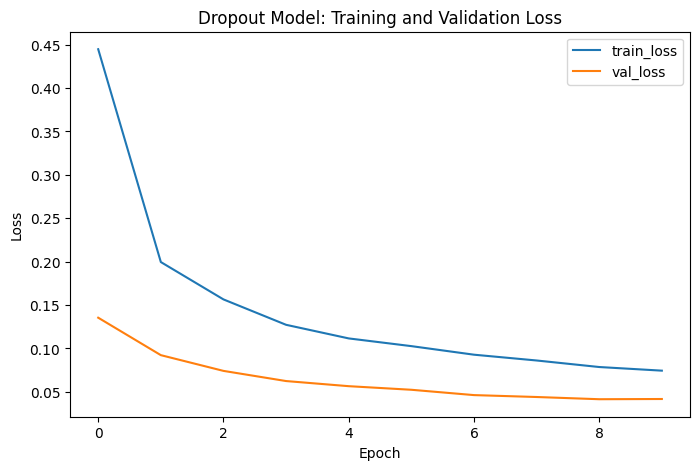

In [170]:
plt.figure(figsize=(8, 5))
plt.plot(history_dropout.history["loss"], label="train_loss")
plt.plot(history_dropout.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Dropout Model: Training and Validation Loss")
plt.legend()
plt.savefig("dropout_plot.png")
plt.show()